<a href="https://colab.research.google.com/github/al-dum/1/blob/main/XRAY_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###1. Importaciones
Se cargan todas las librerías necesarias desde el principio. PyTorch y torchvision gestionan la red neuronal y el procesamiento de imágenes, PIL abre imágenes individuales, matplotlib y seaborn producen las visualizaciones, sklearn proporciona las métricas de evaluación y kagglehub descarga el dataset directamente desde Kaggle.

In [ ]:
import os
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import kagglehub


###2  Reproducibilidad y Configuración del Dispositivo
Se aplica una semilla aleatoria fija a Python, NumPy y PyTorch para que los resultados sean reproducibles entre ejecuciones. También se configura PyTorch para comportarse de forma determinista, evitando diferencias sutiles causadas por el paralelismo de la GPU. Finalmente se detecta si hay una GPU disponible y se configura el dispositivo en consecuencia.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


###3. Descarga del Dataset
El dataset se descarga directamente desde Kaggle al entorno de Colab usando kagglehub. Esto evita tener que subir archivos manualmente y hace que el notebook sea autocontenido y fácil de compartir.

-Nora

In [ ]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


###4. Verificar Estructura de Carpetas
Antes de escribir cualquier código de carga de datos, se imprime el árbol de carpetas real que produjo kagglehub. Esto es importante porque los datasets de Kaggle a veces tienen una estructura anidada inesperada, y equivocarse en la ruta provoca errores de archivo no encontrado.

In [ ]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files[:3]:
            print(f'{indent}  {f}')


chest-xray-pneumonia/
  chest_xray/
    chest_xray/
      val/
        PNEUMONIA/
        NORMAL/
      test/
        PNEUMONIA/
        NORMAL/
      train/
        PNEUMONIA/
        NORMAL/
    __MACOSX/
      chest_xray/
        val/
          PNEUMONIA/
          NORMAL/
        test/
          PNEUMONIA/
          NORMAL/
        train/
          PNEUMONIA/
          NORMAL/
    val/
      PNEUMONIA/
      NORMAL/
    test/
      PNEUMONIA/
      NORMAL/
    train/
      PNEUMONIA/
      NORMAL/


###5. Configuración
Todos los ajustes globales se definen en un solo lugar: tamaño de imagen, tamaño de lote, número de workers, proporción de la división de validación y nombres de los checkpoints. Mantenerlos juntos significa que solo hay que modificar una celda si se quiere experimentar con diferentes configuraciones.

In [ ]:
DATA_DIR = os.path.join(path, "chest_xray")

IMG_SIZE = 299
BATCH_SIZE = 32
NUM_WORKERS = 2
VALIDATION_SPLIT = 0.2

CHECKPOINT_HEAD = 'best_model_299_head.pth'
CHECKPOINT_FINETUNED = 'best_model_299_finetuned.pth'


###6. Transformaciones de Imagen
Se definen dos pipelines de transformación separados. El pipeline de entrenamiento aplica aumento de datos — volteos aleatorios, rotaciones ligeras y ajustes suaves de brillo y contraste — lo que aumenta artificialmente la variedad del dataset para que el modelo aprenda a generalizar en lugar de memorizar. El pipeline de validación y test omite el aumento de datos por completo para que la evaluación sea siempre consistente y sin modificaciones.

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


###7. Carga de Datos y División de Validación
Esta es una de las correcciones clave respecto a la versión original. La carpeta `val` del dataset original contiene solo 16 imágenes, lo cual es demasiado pequeño para medir de forma fiable cómo está rindiendo el modelo durante el entrenamiento. Esta celda construye una división estratificada 80/20 directamente desde el conjunto de entrenamiento, asegurando que ambas clases estén representadas proporcionalmente en la validación. El conjunto de test permanece completamente intacto. También se aplica `WeightedRandomSampler` para contrarrestar el desbalance de clases: hay significativamente más muestras de neumonía que normales, y sin esta corrección el modelo tendería a predecir siempre neumonía.

In [ ]:
# Base dataset without transform so we can split once and then assign transforms cleanly
base_train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'))
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=val_test_transforms)

indices = np.arange(len(base_train_dataset.targets))
train_indices, val_indices = train_test_split(
    indices,
    test_size=VALIDATION_SPLIT,
    stratify=base_train_dataset.targets,
    random_state=SEED,
)

train_dataset = Subset(
    datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms),
    train_indices
)
val_dataset = Subset(
    datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=val_test_transforms),
    val_indices
)

train_targets = np.array(base_train_dataset.targets)[train_indices]
class_counts = np.bincount(train_targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

class_names = base_train_dataset.classes

print('Classes:', class_names)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Class counts in TRAIN split — NORMAL: {class_counts[0]} | PNEUMONIA: {class_counts[1]}')


Classes: ['NORMAL', 'PNEUMONIA']
Train: 4172 | Val: 1044 | Test: 624
Class counts in TRAIN split — NORMAL: 1073 | PNEUMONIA: 3099


###8. Visualizar Imágenes de Muestra
Se muestra una cuadrícula de 8 imágenes de entrenamiento con sus etiquetas antes de comenzar el entrenamiento. Es una verificación estándar que confirma que las imágenes se cargaron correctamente, las etiquetas son correctas y los aumentos de datos se están aplicando como se espera. Saltarse este paso es un error habitual que lleva a desperdiciar tiempo de entrenamiento depurando problemas de datos invisibles.

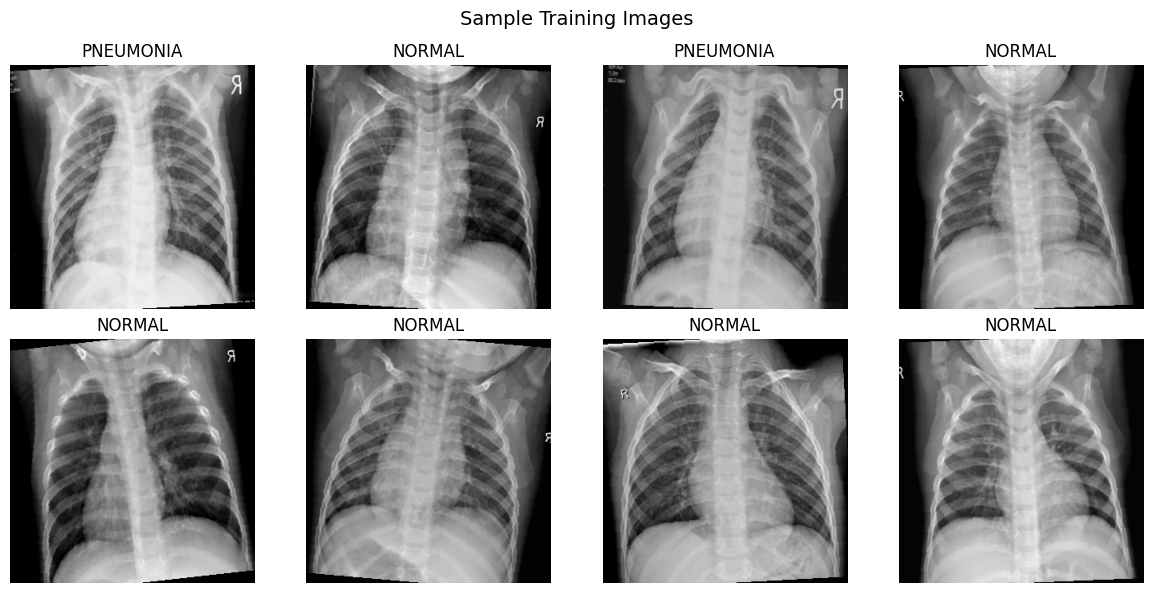

In [ ]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis('off')

plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()


###9. Construcción del Modelo
En lugar de diseñar una CNN desde cero, se usa ResNet18 preentrenado en ImageNet. La idea del aprendizaje por transferencia es que el modelo ya aprendió a detectar patrones visuales generales como bordes y texturas a partir de más de un millón de imágenes, así que conservamos todo eso y solo reemplazamos la capa de clasificación final por una propia que produce 2 clases en lugar de 1000. El backbone se congela inicialmente para que solo se entrene la nueva cabeza al principio, lo cual es más estable al trabajar con un dataset relativamente pequeño.

In [ ]:
def build_model(num_classes=2, freeze_backbone=True):
    model = models.resnet18(weights='IMAGENET1K_V1')

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes=2, freeze_backbone=True).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


Trainable parameters: 131,842 / 11,308,354


###10. Configuración del Entrenamiento
Se configuran tres componentes. La función de pérdida es `CrossEntropyLoss` con pesos de clase, añadiendo una segunda capa de corrección del desbalance además del sampler al penalizar más los errores en la clase minoritaria. El optimizador es Adam, la elección estándar para la mayoría de tareas de deep learning por su tasa de aprendizaje adaptativa. El scheduler monitoriza la pérdida de validación y reduce automáticamente la tasa de aprendizaje si deja de mejorar, evitando que el modelo se quede estancado.


In [ ]:
weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)


###11. Funciones de Entrenamiento y Evaluación
Se definen dos funciones reutilizables para mantener el bucle de entrenamiento limpio. `train_one_epoch` ejecuta el modelo en modo entrenamiento, calcula predicciones, calcula la pérdida y actualiza los pesos mediante retropropagación. `evaluate` ejecuta el modelo en modo evaluación con los gradientes desactivados, lo cual es más rápido y asegura que la normalización por lotes y el dropout se comporten correctamente durante la validación.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


###12. Bucle de Entrenamiento de la Cabeza
La cabeza clasificadora se entrena durante 12 épocas mientras el backbone de ResNet permanece congelado. Después de cada época se evalúa en el conjunto de validación para detectar sobreajuste. El mejor estado del modelo — el que tiene la menor pérdida de validación — se guarda en disco usando `copy.deepcopy` para capturar los pesos exactos en ese momento, no el estado final tras la última época.

In [ ]:
EPOCHS = 12
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_head_state = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_head_state = copy.deepcopy(model.state_dict())
        torch.save(best_head_state, CHECKPOINT_HEAD)

    print(f'Epoch [{epoch+1:02d}/{EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print(f'Head training complete. Best model saved to {CHECKPOINT_HEAD}')


Epoch [01/12] Train Loss: 0.2832 Acc: 0.8332 | Val Loss: 0.2977 Acc: 0.8180
Epoch [02/12] Train Loss: 0.1848 Acc: 0.9080 | Val Loss: 0.2034 Acc: 0.8793
Epoch [03/12] Train Loss: 0.1680 Acc: 0.9120 | Val Loss: 0.2150 Acc: 0.8716
Epoch [04/12] Train Loss: 0.1530 Acc: 0.9228 | Val Loss: 0.2089 Acc: 0.8736
Epoch [05/12] Train Loss: 0.1571 Acc: 0.9197 | Val Loss: 0.1673 Acc: 0.9013
Epoch [06/12] Train Loss: 0.1629 Acc: 0.9207 | Val Loss: 0.5780 Acc: 0.6839
Epoch [07/12] Train Loss: 0.1297 Acc: 0.9338 | Val Loss: 0.2318 Acc: 0.8669
Epoch [08/12] Train Loss: 0.1308 Acc: 0.9302 | Val Loss: 0.1083 Acc: 0.9492
Epoch [09/12] Train Loss: 0.1274 Acc: 0.9386 | Val Loss: 0.2027 Acc: 0.8764
Epoch [10/12] Train Loss: 0.1299 Acc: 0.9341 | Val Loss: 0.1035 Acc: 0.9540
Epoch [11/12] Train Loss: 0.1442 Acc: 0.9283 | Val Loss: 0.1560 Acc: 0.9071
Epoch [12/12] Train Loss: 0.1368 Acc: 0.9305 | Val Loss: 0.1006 Acc: 0.9540
Head training complete. Best model saved to best_model_299_head.pth


###13. Curvas de Entrenamiento
Se grafican la pérdida y la precisión tanto de entrenamiento como de validación a lo largo de todas las épocas. Tener ambas curvas en el mismo gráfico es la forma estándar de diagnosticar el comportamiento del entrenamiento: si la precisión de entrenamiento sube pero la de validación se estanca o baja, hay sobreajuste. Mostrar estas curvas en una presentación demuestra que se monitorizó activamente el entrenamiento en lugar de ejecutarlo a ciegas.

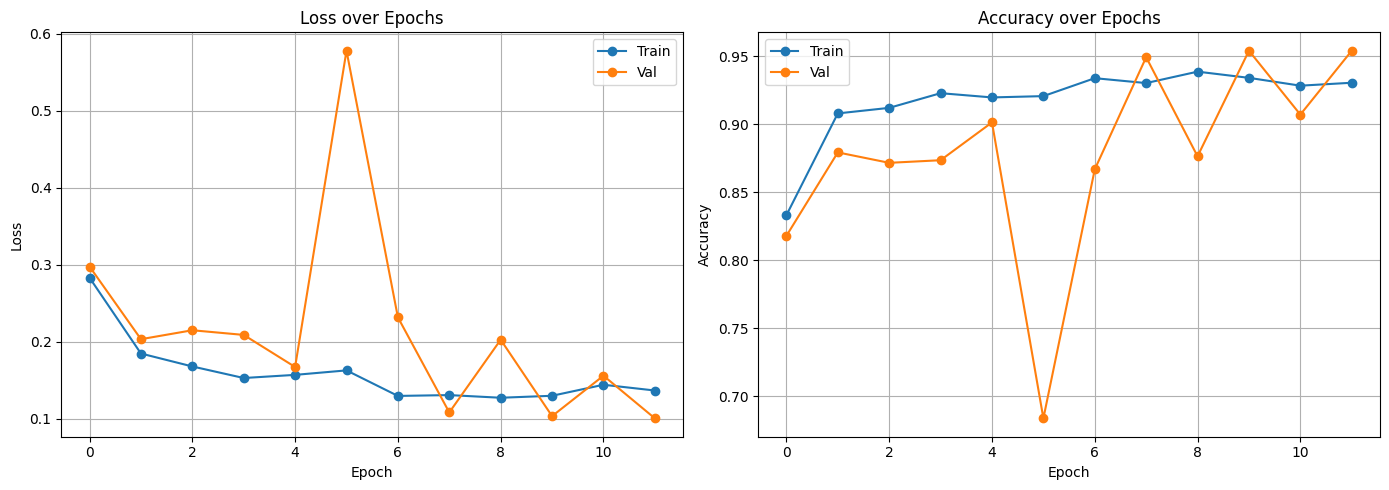

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], marker='o', label='Train')
axes[0].plot(history['val_loss'], marker='o', label='Val')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], marker='o', label='Train')
axes[1].plot(history['val_acc'], marker='o', label='Val')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


###14. Fine-tuning
Se carga el mejor checkpoint de la cabeza y se descongelan todas las capas. Toda la red se entrena entonces de extremo a extremo con una tasa de aprendizaje mucho más pequeña de 1e-5, frente al 1e-3 del entrenamiento de la cabeza. Esto permite que las características preentrenadas de ResNet se adapten ligeramente a las imágenes de rayos X, que son muy diferentes de las fotografías cotidianas con las que se construyó ImageNet. La tasa de aprendizaje pequeña es crítica: demasiado grande y se sobreescribirían los pesos preentrenados perdiendo todo lo aprendido. Este paso normalmente añade un 1-3% de precisión adicional.

In [ ]:
# Fine-tune the full network starting from the best head-only checkpoint
model.load_state_dict(torch.load(CHECKPOINT_HEAD, map_location=device))
for param in model.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(model.parameters(), lr=1e-5)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', patience=2, factor=0.5)

FINETUNE_EPOCHS = 5
finetune_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss_ft = float('inf')
best_ft_state = None

for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler_ft.step(val_loss)

    finetune_history['train_loss'].append(train_loss)
    finetune_history['val_loss'].append(val_loss)
    finetune_history['train_acc'].append(train_acc)
    finetune_history['val_acc'].append(val_acc)

    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        best_ft_state = copy.deepcopy(model.state_dict())
        torch.save(best_ft_state, CHECKPOINT_FINETUNED)

    print(f'Finetune Epoch [{epoch+1:02d}/{FINETUNE_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print(f'Fine-tuning complete. Best model saved to {CHECKPOINT_FINETUNED}')


Finetune Epoch [01/5] Train Loss: 0.0876 Acc: 0.9595 | Val Loss: 0.0768 Acc: 0.9540
Finetune Epoch [02/5] Train Loss: 0.0733 Acc: 0.9643 | Val Loss: 0.0745 Acc: 0.9598
Finetune Epoch [03/5] Train Loss: 0.0492 Acc: 0.9767 | Val Loss: 0.0517 Acc: 0.9732
Finetune Epoch [04/5] Train Loss: 0.0379 Acc: 0.9830 | Val Loss: 0.0634 Acc: 0.9626
Finetune Epoch [05/5] Train Loss: 0.0353 Acc: 0.9823 | Val Loss: 0.0471 Acc: 0.9741
Fine-tuning complete. Best model saved to best_model_299_finetuned.pth


###15. Evaluación en el Conjunto de Test
Se carga el mejor checkpoint fine-tuneado y se evalúa sobre el conjunto de test, que nunca ha sido visto durante ninguna parte del entrenamiento ni la validación. El informe de clasificación desglosa la precisión, el recall y el F1-score por clase. En aplicaciones médicas el recall es especialmente importante porque un falso negativo — no detectar neumonía en un paciente enfermo — es mucho más peligroso que un falso positivo. La matriz de confusión visualiza exactamente dónde comete errores el modelo.

=== Classification Report ===
              precision    recall  f1-score   support

      NORMAL       0.99      0.70      0.82       234
   PNEUMONIA       0.85      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.92      0.85      0.87       624
weighted avg       0.90      0.88      0.88       624



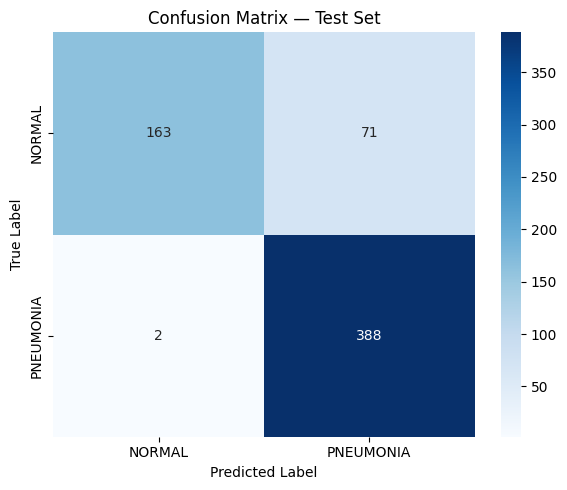

In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_FINETUNED, map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


###16. Función Predictora de Imagen Individual
Una función reutilizable que toma cualquier ruta de imagen de rayos X, la preprocesa de forma idéntica al entrenamiento, la pasa por el modelo fine-tuneado e imprime la etiqueta predicha, la etiqueta real, la puntuación de confianza y el desglose completo de probabilidades para ambas clases. También muestra la imagen del rayos X junto a la predicción, lo que resulta muy atractivo en una demo en vivo.


In [ ]:
def predict_xray(file_path, model, device, class_names):
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img = Image.open(file_path).convert('L')
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = probs.argmax().item()

    pred_label = class_names[pred_idx]
    true_label = os.path.basename(os.path.dirname(file_path))

    print(f'File: {os.path.basename(file_path)}')
    print(f'True label: {true_label}')
    print(f'Predicted: {pred_label}')
    print(f'Confidence: {probs[pred_idx].item()*100:.2f}%')
    print('Class probabilities:')
    for i, name in enumerate(class_names):
        print(f'  {name:<12} {probs[i].item()*100:6.2f}%')

    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(f'Predicted: {pred_label} ({probs[pred_idx].item()*100:.1f}%) | True: {true_label}')
    plt.axis('off')
    plt.show()


###17. Demo con Una Imagen
Se llama a la función predictora sobre una imagen del conjunto de test. Es la versión más simple de la demo, útil para verificar rápidamente que el predictor funciona antes de ejecutarlo sobre un lote más grande.

File: NORMAL2-IM-0336-0001.jpeg
True label: NORMAL
Predicted: NORMAL
Confidence: 51.37%
Class probabilities:
  NORMAL        51.37%
  PNEUMONIA     48.63%


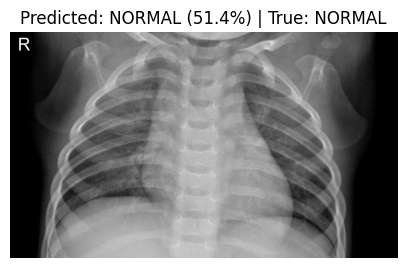

In [ ]:
# Test one image
sample_file = os.path.join(DATA_DIR, 'test', 'NORMAL', os.listdir(os.path.join(DATA_DIR, 'test', 'NORMAL'))[0])
predict_xray(sample_file, model, device, class_names)


###18. Demo con Múltiples Imágenes
Se seleccionan diez imágenes aleatorias del conjunto de test — cinco normales y cinco con neumonía — y se ejecuta el predictor sobre cada una. Esto ofrece una imagen mucho más realista del rendimiento del modelo que un único ejemplo seleccionado a mano, y es la parte visualmente más impactante del notebook para mostrar durante una presentación.

File: IM-0109-0001.jpeg
True label: NORMAL
Predicted: NORMAL
Confidence: 85.87%
Class probabilities:
  NORMAL        85.87%
  PNEUMONIA     14.13%


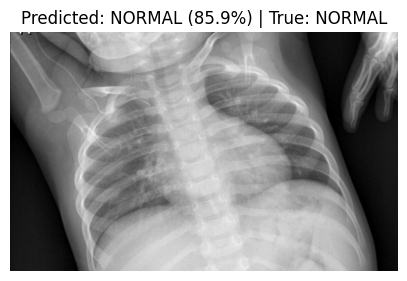

File: NORMAL2-IM-0027-0001.jpeg
True label: NORMAL
Predicted: NORMAL
Confidence: 97.55%
Class probabilities:
  NORMAL        97.55%
  PNEUMONIA      2.45%


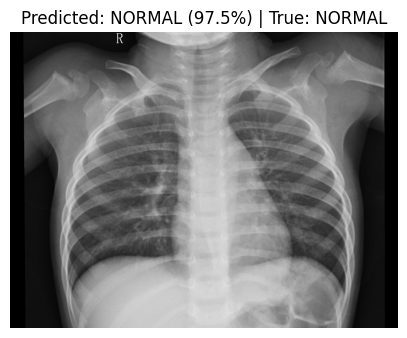

File: NORMAL2-IM-0139-0001.jpeg
True label: NORMAL
Predicted: NORMAL
Confidence: 99.57%
Class probabilities:
  NORMAL        99.57%
  PNEUMONIA      0.43%


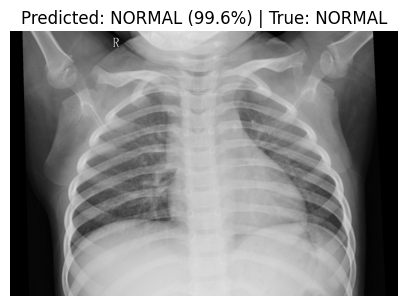

File: NORMAL2-IM-0102-0001.jpeg
True label: NORMAL
Predicted: NORMAL
Confidence: 71.06%
Class probabilities:
  NORMAL        71.06%
  PNEUMONIA     28.94%


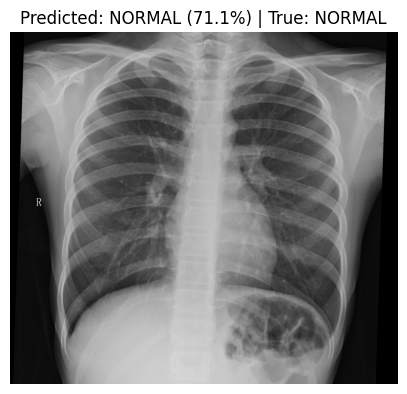

File: NORMAL2-IM-0302-0001.jpeg
True label: NORMAL
Predicted: NORMAL
Confidence: 88.26%
Class probabilities:
  NORMAL        88.26%
  PNEUMONIA     11.74%


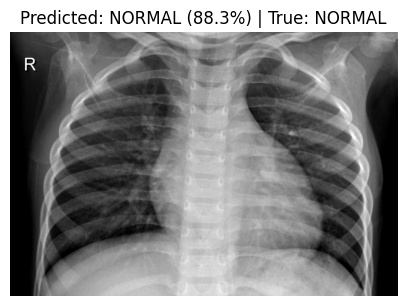

File: person171_bacteria_826.jpeg
True label: PNEUMONIA
Predicted: PNEUMONIA
Confidence: 100.00%
Class probabilities:
  NORMAL         0.00%
  PNEUMONIA    100.00%


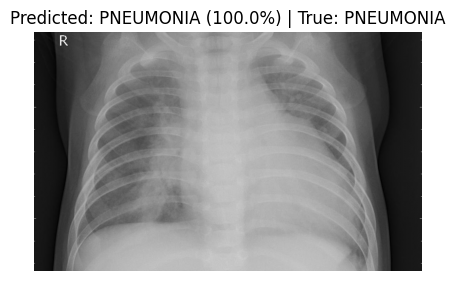

File: person85_bacteria_423.jpeg
True label: PNEUMONIA
Predicted: PNEUMONIA
Confidence: 100.00%
Class probabilities:
  NORMAL         0.00%
  PNEUMONIA    100.00%


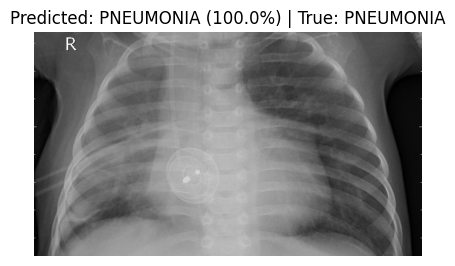

File: person93_bacteria_454.jpeg
True label: PNEUMONIA
Predicted: PNEUMONIA
Confidence: 99.94%
Class probabilities:
  NORMAL         0.06%
  PNEUMONIA     99.94%


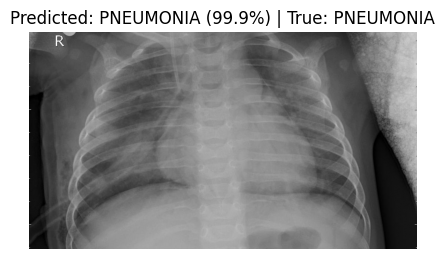

File: person114_bacteria_545.jpeg
True label: PNEUMONIA
Predicted: PNEUMONIA
Confidence: 95.94%
Class probabilities:
  NORMAL         4.06%
  PNEUMONIA     95.94%


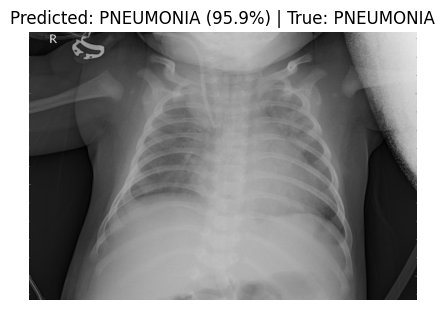

File: person66_virus_125.jpeg
True label: PNEUMONIA
Predicted: PNEUMONIA
Confidence: 99.95%
Class probabilities:
  NORMAL         0.05%
  PNEUMONIA     99.95%


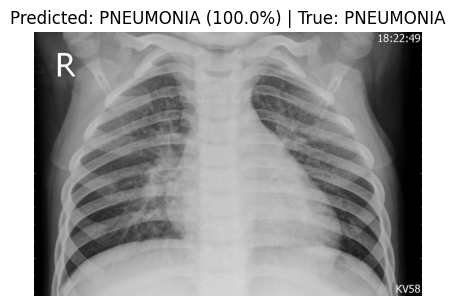

In [ ]:
# Test multiple random images for a more realistic view of performance
normal_dir = os.path.join(DATA_DIR, 'test', 'NORMAL')
pneumonia_dir = os.path.join(DATA_DIR, 'test', 'PNEUMONIA')

sample_files = (
    [os.path.join(normal_dir, f) for f in random.sample(os.listdir(normal_dir), 5)] +
    [os.path.join(pneumonia_dir, f) for f in random.sample(os.listdir(pneumonia_dir), 5)]
)

for file_path in sample_files:
    predict_xray(file_path, model, device, class_names)
